In [1]:
import random
import os
import zipfile
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [2]:
# Random seed
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Seed set to:", seed)
print("Device:", device)

Seed set to: 42
Device: cpu


# Data Loading and Preprocessing

In [3]:
zip_path = "/content/ECE1508Dataset.zip"
extract_path = "/content/metr_la_data"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

for root, dirs, files in os.walk(extract_path):
    print("Folder:", root)
    for f in files:
        print("  ", f)

Folder: /content/metr_la_data
   METR-LA.h5
   adj_METR-LA.pkl


In [4]:
h5_path = None
for root, dirs, files in os.walk("/content/metr_la_data"):
    for f in files:
        if f.endswith(".h5"):
            h5_path = os.path.join(root, f)

print("h5_path =", h5_path)

df = pd.read_hdf(h5_path)
print("shape:", df.shape)
display(df.head())

h5_path = /content/metr_la_data/METR-LA.h5
shape: (34272, 207)


,773869,767541,767542,717447,717446,717445,773062,767620,737529,717816,...,772167,769372,774204,769806,717590,717592,717595,772168,718141,769373
2012-03-01 00:00:00,64.375000,67.625000,67.125000,61.500000,66.875000,68.750000,65.125,67.125,59.625000,62.750000,...,45.625000,65.500,64.500000,66.428571,66.875,59.375000,69.000000,59.250000,69.000000,61.875
2012-03-01 00:05:00,62.666667,68.555556,65.444444,62.444444,64.444444,68.111111,65.000,65.000,57.444444,63.333333,...,50.666667,69.875,66.666667,58.555556,62.000,61.111111,64.444444,55.888889,68.444444,62.875
2012-03-01 00:10:00,64.000000,63.750000,60.000000,59.000000,66.500000,66.250000,64.500,64.250,63.875000,65.375000,...,44.125000,69.000,56.500000,59.250000,68.125,62.500000,65.625000,61.375000,69.857143,62.000
2012-03-01 00:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000,0.000000,0.000000,...,0.000000,0.000,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000
2012-03-01 00:20:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000,0.000000,0.000000,...,0.000000,0.000,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000


In [5]:
print("index type:", type(df.index))
print("first 5 timestamps:", df.index[:5].tolist())
print("first 10 sensor ids:", df.columns[:10].tolist())

index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
first 5 timestamps: [Timestamp('2012-03-01 00:00:00'), Timestamp('2012-03-01 00:05:00'), Timestamp('2012-03-01 00:10:00'), Timestamp('2012-03-01 00:15:00'), Timestamp('2012-03-01 00:20:00')]
first 10 sensor ids: ['773869', '767541', '767542', '717447', '717446', '717445', '773062', '767620', '737529', '717816']


In [6]:
data = df.values

print("data shape:", data.shape)
print(data[:3, :5])

data shape: (34272, 207)
[[64.375      67.625      67.125      61.5        66.875     ]
 [62.66666667 68.55555556 65.44444444 62.44444444 64.44444444]
 [64.         63.75       60.         59.         66.5       ]]


In [7]:
data = np.expand_dims(data, axis=-1)

print("new shape:", data.shape)

new shape: (34272, 207, 1)


In [8]:
def create_sequences(data, input_len=12, pred_len=12):
    X = []
    y = []

    T = data.shape[0]

    for i in range(T - input_len - pred_len + 1):
        X.append(data[i:i + input_len])
        y.append(data[i + input_len:i + input_len + pred_len])

    return np.array(X), np.array(y)

X, y = create_sequences(data, input_len=12, pred_len=12)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (34249, 12, 207, 1)
y shape: (34249, 12, 207, 1)


In [9]:
num_samples = X.shape[0]

train_size = int(num_samples * 0.7)
val_size = int(num_samples * 0.1)
test_size = num_samples - train_size - val_size

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]

X_test = X[train_size + val_size:]
y_test = y[train_size + val_size:]

In [10]:
print("Before reshape:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Before reshape:
X_train: (23974, 12, 207, 1)
y_train: (23974, 12, 207, 1)
X_val: (3424, 12, 207, 1)
y_val: (3424, 12, 207, 1)
X_test: (6851, 12, 207, 1)
y_test: (6851, 12, 207, 1)


# Baseline LSTM

In [11]:
X_train_lstm = X_train.squeeze(-1)
X_val_lstm = X_val.squeeze(-1)
X_test_lstm = X_test.squeeze(-1)

y_train_lstm = y_train.squeeze(-1)
y_val_lstm = y_val.squeeze(-1)
y_test_lstm = y_test.squeeze(-1)

print("After reshape:")
print("X_train_lstm:", X_train_lstm.shape)
print("y_train_lstm:", y_train_lstm.shape)
print("X_val_lstm:", X_val_lstm.shape)
print("y_val_lstm:", y_val_lstm.shape)
print("X_test_lstm:", X_test_lstm.shape)
print("y_test_lstm:", y_test_lstm.shape)

After reshape:
X_train_lstm: (23974, 12, 207)
y_train_lstm: (23974, 12, 207)
X_val_lstm: (3424, 12, 207)
y_val_lstm: (3424, 12, 207)
X_test_lstm: (6851, 12, 207)
y_test_lstm: (6851, 12, 207)


In [12]:
train_mean = X_train_lstm.mean()
train_std = X_train_lstm.std()

X_train_lstm = (X_train_lstm - train_mean) / (train_std + 1e-8)
X_val_lstm = (X_val_lstm - train_mean) / (train_std + 1e-8)
X_test_lstm = (X_test_lstm - train_mean) / (train_std + 1e-8)

y_train_lstm = (y_train_lstm - train_mean) / (train_std + 1e-8)
y_val_lstm = (y_val_lstm - train_mean) / (train_std + 1e-8)
y_test_lstm = (y_test_lstm - train_mean) / (train_std + 1e-8)

print("mean:", train_mean)
print("std:", train_std)

mean: 54.40592829587626
std: 19.493739270573094


In [13]:
X_train_tensor = torch.tensor(X_train_lstm, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_lstm, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val_lstm, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_lstm, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_lstm, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_lstm, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [14]:
class BaselineLSTM(nn.Module):
    def __init__(self, input_size=207, hidden_size=64, num_layers=2, output_size=207, pred_len=12, dropout=0.2):
        super().__init__()
        self.pred_len = pred_len
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.fc = nn.Linear(hidden_size, output_size * pred_len)

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        last_out = out[:, -1, :]
        y_hat = self.fc(last_out)
        return y_hat.view(y_hat.size(0), self.pred_len, -1)

In [15]:
model = BaselineLSTM(
    input_size=207,
    hidden_size=64,
    num_layers=2,
    output_size=207,
    dropout=0.2
).to(device)

criterion = nn.MSELoss()
lstm_optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(model)

BaselineLSTM(
  (lstm): LSTM(207, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=2484, bias=True)
)


In [16]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)

    return total_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            preds = model(X_batch)
            loss = criterion(preds, y_batch)

            total_loss += loss.item() * X_batch.size(0)

    return total_loss / len(loader.dataset)

In [17]:
lstm_train_losses = []
lstm_val_losses = []

num_epochs = 30

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, criterion, lstm_optimizer, device)
    val_loss = evaluate(model, val_loader, criterion, device)

    lstm_train_losses.append(train_loss)
    lstm_val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

Epoch 1/30 | Train Loss: 0.419457 | Val Loss: 0.449514
Epoch 2/30 | Train Loss: 0.307718 | Val Loss: 0.417209
Epoch 3/30 | Train Loss: 0.273996 | Val Loss: 0.400933
Epoch 4/30 | Train Loss: 0.247835 | Val Loss: 0.384008
Epoch 5/30 | Train Loss: 0.234420 | Val Loss: 0.391828
Epoch 6/30 | Train Loss: 0.225728 | Val Loss: 0.396348
Epoch 7/30 | Train Loss: 0.219171 | Val Loss: 0.412187
Epoch 8/30 | Train Loss: 0.214301 | Val Loss: 0.404589
Epoch 9/30 | Train Loss: 0.208361 | Val Loss: 0.413881
Epoch 10/30 | Train Loss: 0.206535 | Val Loss: 0.394773
Epoch 11/30 | Train Loss: 0.199757 | Val Loss: 0.410318
Epoch 12/30 | Train Loss: 0.196946 | Val Loss: 0.412744
Epoch 13/30 | Train Loss: 0.198211 | Val Loss: 0.455108
Epoch 14/30 | Train Loss: 0.193059 | Val Loss: 0.475203
Epoch 15/30 | Train Loss: 0.193981 | Val Loss: 0.426650
Epoch 16/30 | Train Loss: 0.188972 | Val Loss: 0.459224
Epoch 17/30 | Train Loss: 0.187312 | Val Loss: 0.454791
Epoch 18/30 | Train Loss: 0.183821 | Val Loss: 0.444476
E

In [18]:
model.eval()

lstm_all_preds = []
lstm_all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch).cpu()

        lstm_all_preds.append(preds)
        lstm_all_targets.append(y_batch)

lstm_all_preds = torch.cat(lstm_all_preds, dim=0).numpy()
lstm_all_targets = torch.cat(lstm_all_targets, dim=0).numpy()

print("pred shape:", lstm_all_preds.shape)
print("target shape:", lstm_all_targets.shape)

pred shape: (6851, 12, 207)
target shape: (6851, 12, 207)


In [19]:
lstm_preds_denorm = lstm_all_preds * (train_std + 1e-8) + train_mean
lstm_targets_denorm = lstm_all_targets * (train_std + 1e-8) + train_mean

In [20]:
def MAE(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def RMSE(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def MAPE(y_true, y_pred):
    mask = y_true > 10
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def evaluate_multistep(targets, preds, horizons=[3, 6, 12]):
    print(f"{'Horizon':<10} {'MAE':>10} {'RMSE':>10} {'MAPE':>10}")
    print("=" * 45)
    for h in horizons:
        t = targets[:, h-1, :]
        p = preds[:, h-1, :]
        mae  = MAE(t, p)
        rmse = RMSE(t, p)
        mape = MAPE(t, p)
        print(f"{f'H{h} ({h*5}min)':<10} {mae:>10.4f} {rmse:>10.4f} {mape:>10.2f}%")
    print("=" * 45)
    overall_mae = MAE(targets, preds)
    overall_rmse = RMSE(targets, preds)
    overall_mape = MAPE(targets, preds)
    print(f"{'Overall':<10} {overall_mae:>10.4f} {overall_rmse:>10.4f} {overall_mape:>10.2f}%")

In [21]:
print("=== LSTM Results ===")
evaluate_multistep(lstm_targets_denorm, lstm_preds_denorm, horizons=[3, 6, 12])

=== LSTM Results ===
Horizon           MAE       RMSE       MAPE
H3 (15min)     8.3570    16.3646      15.10%
H6 (30min)     9.2017    17.9050      16.43%
H12 (60min)    10.6461    19.5669      18.31%
Overall        9.2287    17.7909      16.41%


# Temporal CNN baseline

In [22]:
X_train_tcn = X_train_lstm[..., np.newaxis]
X_val_tcn = X_val_lstm[..., np.newaxis]
X_test_tcn = X_test_lstm[..., np.newaxis]

y_train_tcn = y_train_lstm
y_val_tcn = y_val_lstm
y_test_tcn = y_test_lstm

print("X_train:", X_train_tcn.shape)
print("y_train:", y_train_tcn.shape)
print("mean check:", X_train_tcn.mean())

X_train: (23974, 12, 207, 1)
y_train: (23974, 12, 207)
mean check: -7.869187154418953e-15


In [23]:
X_train_tcn_tensor = torch.tensor(X_train_tcn, dtype=torch.float32)
y_train_tcn_tensor = torch.tensor(y_train_tcn, dtype=torch.float32)

X_val_tcn_tensor = torch.tensor(X_val_tcn, dtype=torch.float32)
y_val_tcn_tensor = torch.tensor(y_val_tcn, dtype=torch.float32)

X_test_tcn_tensor  = torch.tensor(X_test_tcn, dtype=torch.float32)
y_test_tcn_tensor  = torch.tensor(y_test_tcn, dtype=torch.float32)

print(X_train_tcn_tensor.shape)
print(y_train_tcn_tensor.shape)

torch.Size([23974, 12, 207, 1])
torch.Size([23974, 12, 207])


In [24]:
train_dataset = TensorDataset(X_train_tcn_tensor, y_train_tcn_tensor)
val_dataset = TensorDataset(X_val_tcn_tensor, y_val_tcn_tensor)
test_dataset = TensorDataset(X_test_tcn_tensor, y_test_tcn_tensor)

train_loader_tcn = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader_tcn = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader_tcn = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [25]:
class TemporalCNN(nn.Module):
    def __init__(self, in_channels=1, hidden_channels=32, pred_len=12):
        super().__init__()
        self.pred_len = pred_len
        self.conv1 = nn.Conv2d(in_channels, hidden_channels, kernel_size=(3, 1), padding=(1, 0))
        self.conv2 = nn.Conv2d(hidden_channels, hidden_channels, kernel_size=(3, 1), padding=(1, 0))
        self.relu = nn.ReLU()
        self.final = nn.Conv2d(hidden_channels, pred_len, kernel_size=(1, 1))

    def forward(self, X):
        X = X.permute(0, 3, 1, 2)
        X = self.relu(self.conv1(X))
        X = self.relu(self.conv2(X))
        out = self.final(X)
        out = out[:, :, -1, :]
        return out

In [26]:
tcn_model = TemporalCNN(in_channels=1, hidden_channels=32).to(device)

criterion = nn.MSELoss()
tcn_optimizer = torch.optim.Adam(tcn_model.parameters(), lr=1e-3)

print(tcn_model)

TemporalCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 1), stride=(1, 1), padding=(1, 0))
  (conv2): Conv2d(32, 32, kernel_size=(3, 1), stride=(1, 1), padding=(1, 0))
  (relu): ReLU()
  (final): Conv2d(32, 12, kernel_size=(1, 1), stride=(1, 1))
)


In [27]:
def train_epoch_tcn(model, loader, optimizer):
    model.train()
    total_loss = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        preds = model(X_batch)
        loss = criterion(preds, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)

    return total_loss / len(loader.dataset)


def eval_epoch_tcn(model, loader):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            preds = model(X_batch)
            loss = criterion(preds, y_batch)

            total_loss += loss.item() * X_batch.size(0)

    return total_loss / len(loader.dataset)

In [28]:
tcn_train_losses = []
tcn_val_losses = []

epochs = 30

for epoch in range(epochs):
    train_loss = train_epoch_tcn(tcn_model, train_loader_tcn, tcn_optimizer)
    val_loss = eval_epoch_tcn(tcn_model, val_loader_tcn)

    tcn_train_losses.append(train_loss)
    tcn_val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss}")
    print(f"Val Loss: {val_loss}")

Epoch 1/30
Train Loss: 0.32649326411231977
Val Loss: 0.3274146067065613
Epoch 2/30
Train Loss: 0.2983558309382033
Val Loss: 0.32562722516394105
Epoch 3/30
Train Loss: 0.2975298093515788
Val Loss: 0.3262739188133556
Epoch 4/30
Train Loss: 0.29738203312633255
Val Loss: 0.32988242138281604
Epoch 5/30
Train Loss: 0.29735053116658455
Val Loss: 0.329280019067576
Epoch 6/30
Train Loss: 0.2973740108257101
Val Loss: 0.3282671659210018
Epoch 7/30
Train Loss: 0.29678550695989114
Val Loss: 0.3251992247163135
Epoch 8/30
Train Loss: 0.2967038367671128
Val Loss: 0.3252622666028894
Epoch 9/30
Train Loss: 0.2966434338355448
Val Loss: 0.32709282626197717
Epoch 10/30
Train Loss: 0.29645131734858127
Val Loss: 0.3248331748366913
Epoch 11/30
Train Loss: 0.29596658914478247
Val Loss: 0.3258863502643376
Epoch 12/30
Train Loss: 0.2961875950985817
Val Loss: 0.3252081262800738
Epoch 13/30
Train Loss: 0.2953970091433126
Val Loss: 0.32905854505843646
Epoch 14/30
Train Loss: 0.2958452018392566
Val Loss: 0.326546933

In [29]:
tcn_model.eval()

tcn_all_preds = []
tcn_all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader_tcn:
        X_batch = X_batch.to(device)
        preds = tcn_model(X_batch).cpu()

        tcn_all_preds.append(preds)
        tcn_all_targets.append(y_batch)

tcn_all_preds = torch.cat(tcn_all_preds).numpy()
tcn_all_targets = torch.cat(tcn_all_targets).numpy()

print(tcn_all_preds.shape)

(6851, 12, 207)


In [30]:
tcn_preds_denorm   = tcn_all_preds   * (train_std + 1e-8) + train_mean
tcn_targets_denorm = tcn_all_targets * (train_std + 1e-8) + train_mean

In [31]:
print("=== Temporal CNN Results ===")
evaluate_multistep(tcn_targets_denorm, tcn_preds_denorm, horizons=[3, 6, 12])

=== Temporal CNN Results ===
Horizon           MAE       RMSE       MAPE
H3 (15min)     4.3149     9.5264       8.97%
H6 (30min)     6.1603    12.1292      12.06%
H12 (60min)     8.5245    15.0558      16.44%
Overall        6.1456    12.1520      12.08%


# STGCN

In [32]:
pkl_path = "/content/metr_la_data/adj_METR-LA.pkl"

with open(pkl_path, "rb") as f:
    sensor_ids, sensor_id_to_ind, adj_mx = pickle.load(f, encoding="latin1")

print("adj_mx shape:", adj_mx.shape)
print("num sensors:", len(sensor_ids))
print("adj sample:")
print(adj_mx[:5, :5])

adj_mx shape: (207, 207)
num sensors: 207
adj sample:
[[1.         0.         0.         0.         0.        ]
 [0.         1.         0.3909554  0.         0.        ]
 [0.         0.7174379  1.         0.         0.        ]
 [0.         0.         0.         1.         0.63372165]
 [0.         0.         0.         0.62646437 1.        ]]


In [33]:
A = adj_mx

# add self-loop
A_hat = A + np.eye(A.shape[0])

# degree matrix
D = np.diag(np.sum(A_hat, axis=1))

# D^(-1/2)
D_inv_sqrt = np.linalg.inv(np.sqrt(D))

# normalized adjacency
A_norm = D_inv_sqrt @ A_hat @ D_inv_sqrt

print("A_norm shape:", A_norm.shape)
print(A_norm[:5, :5])

A_norm shape: (207, 207)
[[0.34019118 0.         0.         0.         0.        ]
 [0.         0.41601695 0.07421152 0.         0.        ]
 [0.         0.13618474 0.34644732 0.         0.        ]
 [0.         0.         0.         0.27213984 0.08519316]
 [0.         0.         0.         0.08421754 0.2656319 ]]


In [34]:
A_norm = torch.tensor(A_norm, dtype=torch.float32).to(device)

print(A_norm.shape)

torch.Size([207, 207])


In [35]:
class GraphConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.linear = nn.Linear(in_channels, out_channels)

    def forward(self, X, A_norm):
        # X shape: (batch, nodes, features)
        AX = torch.matmul(A_norm, X)
        out = self.linear(AX)
        return out

In [36]:
class TemporalConv(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3):
        super().__init__()
        self.conv = nn.Conv2d(
            in_channels,
            out_channels,
            (kernel_size,1),
            padding=(kernel_size//2,0)
        )

    def forward(self, X):
        return self.conv(X)

In [37]:
class STGCNBlock(nn.Module):
    def __init__(self, in_channels, spatial_channels, out_channels):
        super().__init__()

        self.temp1 = TemporalConv(in_channels, spatial_channels)
        self.graph_conv = GraphConv(spatial_channels, spatial_channels)
        self.temp2 = TemporalConv(spatial_channels, out_channels)

        self.relu = nn.ReLU()

    def forward(self, X, A_norm):
        t = self.temp1(X)
        t = self.relu(t)

        B, C, T, N = t.shape
        t = t.permute(0,2,3,1).reshape(B*T, N, C)

        t = self.graph_conv(t, A_norm)

        t = t.reshape(B, T, N, C).permute(0,3,1,2)

        t = self.temp2(t)
        return self.relu(t)

In [38]:
class STGCN(nn.Module):
    def __init__(self, num_nodes=207, pred_len=12):
        super().__init__()
        self.pred_len = pred_len
        self.block1 = STGCNBlock(1, 32, 32)
        self.block2 = STGCNBlock(32, 32, 32)
        self.final = nn.Conv2d(32, pred_len, (1, 1))

    def forward(self, X, A_norm):
        X = X.permute(0, 3, 1, 2)
        X = self.block1(X, A_norm)
        X = self.block2(X, A_norm)
        out = self.final(X)
        out = out[:, :, -1, :]
        return out

In [39]:
stgcn = STGCN().to(device)

criterion = nn.MSELoss()
stgcn_optimizer = torch.optim.Adam(stgcn.parameters(), lr=1e-3)

print(stgcn)

STGCN(
  (block1): STGCNBlock(
    (temp1): TemporalConv(
      (conv): Conv2d(1, 32, kernel_size=(3, 1), stride=(1, 1), padding=(1, 0))
    )
    (graph_conv): GraphConv(
      (linear): Linear(in_features=32, out_features=32, bias=True)
    )
    (temp2): TemporalConv(
      (conv): Conv2d(32, 32, kernel_size=(3, 1), stride=(1, 1), padding=(1, 0))
    )
    (relu): ReLU()
  )
  (block2): STGCNBlock(
    (temp1): TemporalConv(
      (conv): Conv2d(32, 32, kernel_size=(3, 1), stride=(1, 1), padding=(1, 0))
    )
    (graph_conv): GraphConv(
      (linear): Linear(in_features=32, out_features=32, bias=True)
    )
    (temp2): TemporalConv(
      (conv): Conv2d(32, 32, kernel_size=(3, 1), stride=(1, 1), padding=(1, 0))
    )
    (relu): ReLU()
  )
  (final): Conv2d(32, 12, kernel_size=(1, 1), stride=(1, 1))
)


In [40]:
def train_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        preds = model(X_batch, A_norm)
        loss = criterion(preds, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)

    return total_loss / len(loader.dataset)

In [41]:
def eval_epoch(model, loader):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            preds = model(X_batch, A_norm)
            loss = criterion(preds, y_batch)

            total_loss += loss.item() * X_batch.size(0)

    return total_loss / len(loader.dataset)

In [42]:
stgcn_train_losses = []
stgcn_val_losses = []

epochs = 30

for epoch in range(epochs):
    train_loss = train_epoch(stgcn, train_loader_tcn, stgcn_optimizer)
    val_loss = eval_epoch(stgcn, val_loader_tcn)

    stgcn_train_losses.append(train_loss)
    stgcn_val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{epochs}")
    print("Train Loss:", train_loss)
    print("Val Loss:", val_loss)

Epoch 1/30
Train Loss: 0.4586554471506849
Val Loss: 0.4800769245234605
Epoch 2/30
Train Loss: 0.4174669815942644
Val Loss: 0.4463720336974224
Epoch 3/30
Train Loss: 0.40029898172991385
Val Loss: 0.43342834195801033
Epoch 4/30
Train Loss: 0.38233998574734807
Val Loss: 0.4204650281049381
Epoch 5/30
Train Loss: 0.3729339802350693
Val Loss: 0.4291685935214301
Epoch 6/30
Train Loss: 0.3664548622725992
Val Loss: 0.4186630634086154
Epoch 7/30
Train Loss: 0.358831075509376
Val Loss: 0.40337715437200583
Epoch 8/30
Train Loss: 0.35263410294146436
Val Loss: 0.3984863056897003
Epoch 9/30
Train Loss: 0.34710554161371715
Val Loss: 0.38103470115739607
Epoch 10/30
Train Loss: 0.34340888815227677
Val Loss: 0.38616518791173104
Epoch 11/30
Train Loss: 0.3400365995925193
Val Loss: 0.3775971543705352
Epoch 12/30
Train Loss: 0.3378308865916016
Val Loss: 0.3748023418413701
Epoch 13/30
Train Loss: 0.33531802122951143
Val Loss: 0.37484139983899123
Epoch 14/30
Train Loss: 0.33368123769561236
Val Loss: 0.3690166

In [43]:
stgcn.eval()

stgcn_all_preds = []
stgcn_all_targets = []

with torch.no_grad():

    for X_batch, y_batch in test_loader_tcn:

        X_batch = X_batch.to(device)

        preds = stgcn(X_batch, A_norm).cpu()

        stgcn_all_preds.append(preds)
        stgcn_all_targets.append(y_batch)

stgcn_all_preds = torch.cat(stgcn_all_preds).numpy()
stgcn_all_targets = torch.cat(stgcn_all_targets).numpy()

print(stgcn_all_preds.shape)

(6851, 12, 207)


In [44]:
stgcn_preds_denorm = stgcn_all_preds * (train_std + 1e-8) + train_mean
stgcn_targets_denorm = stgcn_all_targets * (train_std + 1e-8) + train_mean

In [45]:
print("=== STGCN Results ===")
evaluate_multistep(stgcn_targets_denorm, stgcn_preds_denorm, horizons=[3, 6, 12])

=== STGCN Results ===
Horizon           MAE       RMSE       MAPE
H3 (15min)     5.5824    10.3930      11.16%
H6 (30min)     7.0579    12.6495      13.47%
H12 (60min)     9.2254    15.3064      17.27%
Overall        7.1258    12.6753      13.66%


In [46]:
print("=== All Model Results ===")
print("\nLSTM:")
evaluate_multistep(lstm_targets_denorm, lstm_preds_denorm)
print("\nTemporal CNN:")
evaluate_multistep(tcn_targets_denorm, tcn_preds_denorm)
print("\nSTGCN:")
evaluate_multistep(stgcn_targets_denorm, stgcn_preds_denorm)

=== All Model Results ===

LSTM:
Horizon           MAE       RMSE       MAPE
H3 (15min)     8.3570    16.3646      15.10%
H6 (30min)     9.2017    17.9050      16.43%
H12 (60min)    10.6461    19.5669      18.31%
Overall        9.2287    17.7909      16.41%

Temporal CNN:
Horizon           MAE       RMSE       MAPE
H3 (15min)     4.3149     9.5264       8.97%
H6 (30min)     6.1603    12.1292      12.06%
H12 (60min)     8.5245    15.0558      16.44%
Overall        6.1456    12.1520      12.08%

STGCN:
Horizon           MAE       RMSE       MAPE
H3 (15min)     5.5824    10.3930      11.16%
H6 (30min)     7.0579    12.6495      13.47%
H12 (60min)     9.2254    15.3064      17.27%
Overall        7.1258    12.6753      13.66%


# Evaluation and Visualization

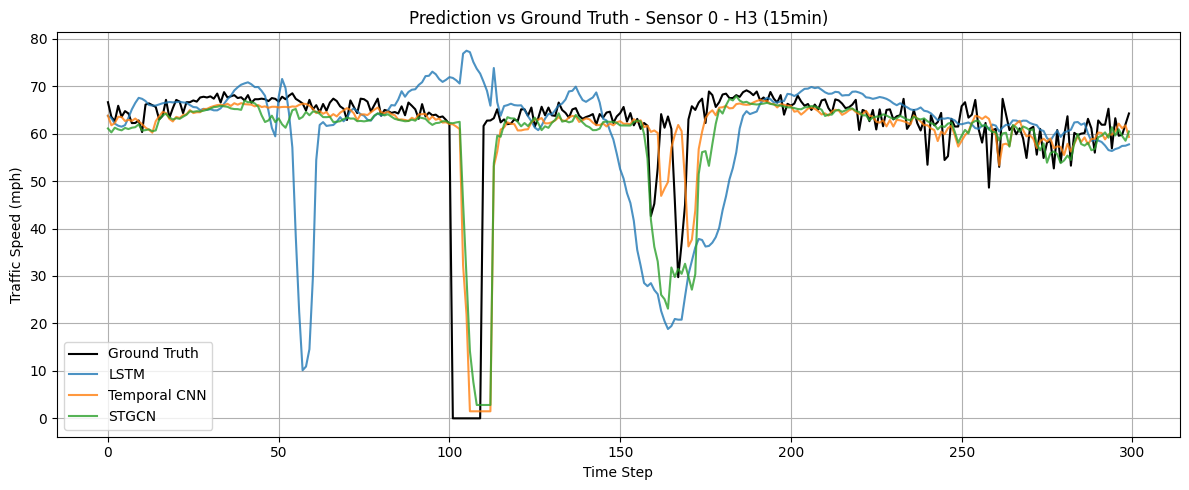

In [47]:
horizon = 3
sensor_idx = 0
num_points = 300

plt.figure(figsize=(12, 5))
plt.plot(lstm_targets_denorm[:num_points, horizon-1, sensor_idx], label="Ground Truth", color="black")
plt.plot(lstm_preds_denorm[:num_points, horizon-1, sensor_idx], label="LSTM", alpha=0.8)
plt.plot(tcn_preds_denorm[:num_points, horizon-1, sensor_idx], label="Temporal CNN", alpha=0.8)
plt.plot(stgcn_preds_denorm[:num_points, horizon-1, sensor_idx], label="STGCN", alpha=0.8)

plt.xlabel("Time Step")
plt.ylabel("Traffic Speed (mph)")
plt.title(f"Prediction vs Ground Truth - Sensor {sensor_idx} - H{horizon} ({horizon*5}min)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

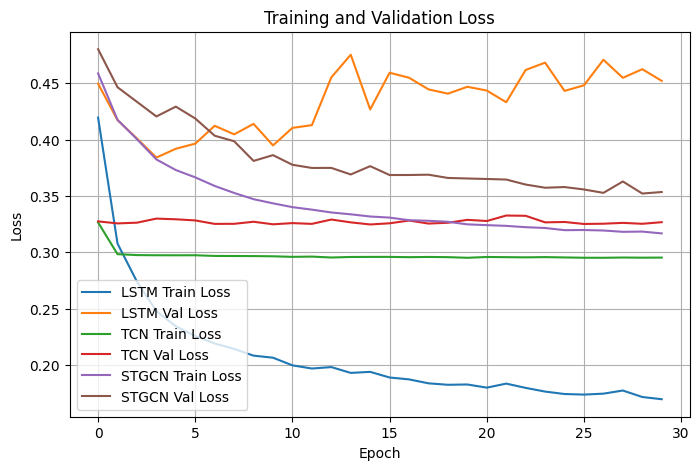

In [48]:
plt.figure(figsize=(8,5))
plt.plot(lstm_train_losses, label="LSTM Train Loss")
plt.plot(lstm_val_losses, label="LSTM Val Loss")
plt.plot(tcn_train_losses, label="TCN Train Loss")
plt.plot(tcn_val_losses, label="TCN Val Loss")
plt.plot(stgcn_train_losses, label="STGCN Train Loss")
plt.plot(stgcn_val_losses, label="STGCN Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [49]:
import subprocess
subprocess.run(["jupyter", "nbconvert", "--to", "html", "/content/ECE1508Project.ipynb"])

CompletedProcess(args=['jupyter', 'nbconvert', '--to', 'html', '/content/ECE1508Project.ipynb'], returncode=255)